# **->Instructor Effectiveness Analysis and Prediction**
This project analyzes instructor performance using multiple learning metrics such as completion rate, dropout rate, engagement levels, and student feedback.

The objective is to identify key factors influencing instructor effectiveness and build a machine learning model to classify instructors into effectiveness tiers.


## **Problem Statement**
Online learning platforms generate extensive data related to student engagement and learning outcomes. However, evaluating instructor performance across multiple courses and batches remains challenging.

This project aims to analyze instructor-level performance using engagement metrics such as completion rate, dropout rate, watch time, assignment submissions, and feedback scores. A machine learning model is then developed to predict instructor effectiveness tiers (Low, Medium, High).

## **Tools and Technologies Used**
• Python  
• Pandas  
• NumPy  
• Matplotlib  
• Seaborn  
• Scikit-learn

## **Import Required Libraries**

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## **Load the Dataset**


In [48]:
df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [12]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


## **Missing Value Analysis**
The dataset was checked for missing values to ensure data quality before proceeding with analysis and model development.

In [13]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


## **Exploratory Data Analysis**
Exploratory Data Analysis is performed to understand the distribution of key engagement and performance metrics in the dataset. Visualizations help identify patterns, variability, and potential relationships among variables.

### **1) Completion Rate Distribution**
The distribution of completion rates shows how frequently courses achieve different completion levels. Higher completion rates may indicate effective instruction and strong student engagement.

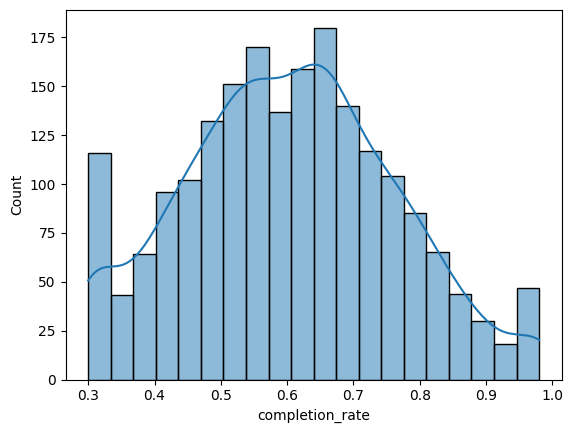

In [14]:
sns.histplot(df["completion_rate"], kde=True)
plt.show()

### **2) Dropout Rate Distribution**
The dropout rate distribution provides insight into student retention across batches. Higher dropout rates may suggest lower engagement or potential challenges in course delivery.

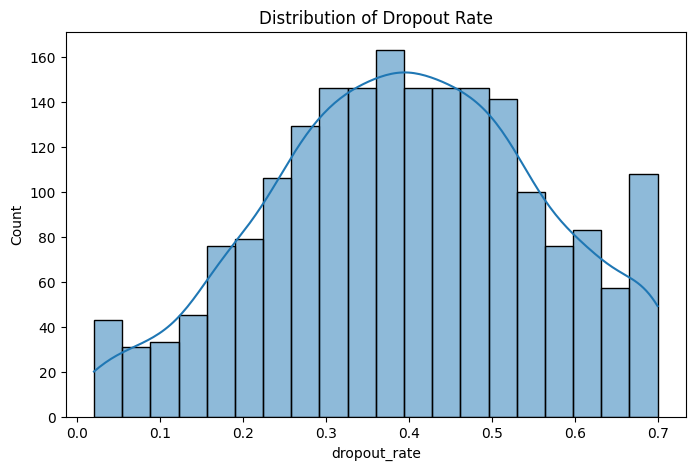

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["dropout_rate"], bins=20, kde=True)
plt.title("Distribution of Dropout Rate")
plt.show()

### **3) Student Feedback Score Distribution**
Student feedback scores provide qualitative insights into instructor performance and course satisfaction levels.

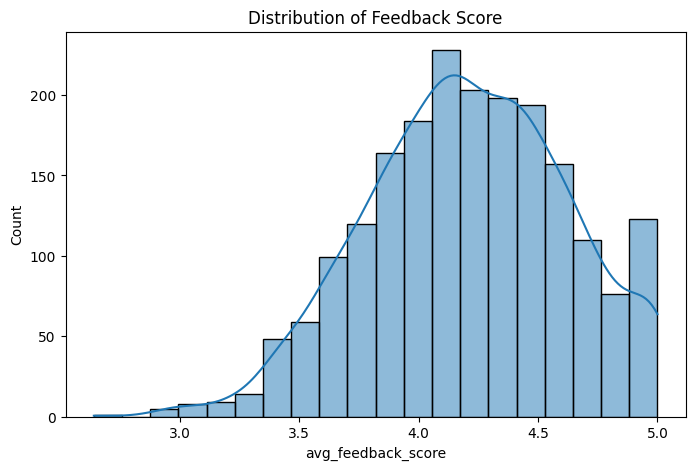

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["avg_feedback_score"], bins=20, kde=True)
plt.title("Distribution of Feedback Score")
plt.show()

### **4) Average Watch Time Distribution**
Watch time represents student engagement with course content. Higher watch time generally reflects stronger learner participation.

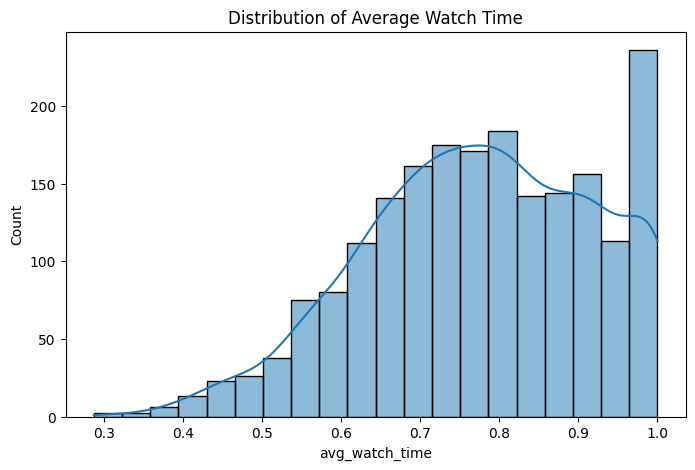

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df["avg_watch_time"], bins=20, kde=True)
plt.title("Distribution of Average Watch Time")
plt.show()

### **5) Assignment Submission Rate Distribution**
Assignment submission rate reflects active participation in coursework and practical learning activities.

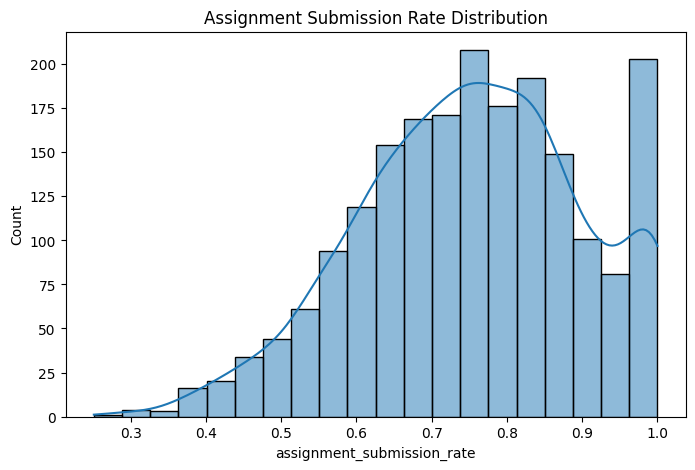

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["assignment_submission_rate"], bins=20, kde=True)
plt.title("Assignment Submission Rate Distribution")
plt.show()

### **6) Forum Activity Rate Distribution**
Forum activity indicates peer interaction and collaborative learning within the course environment.


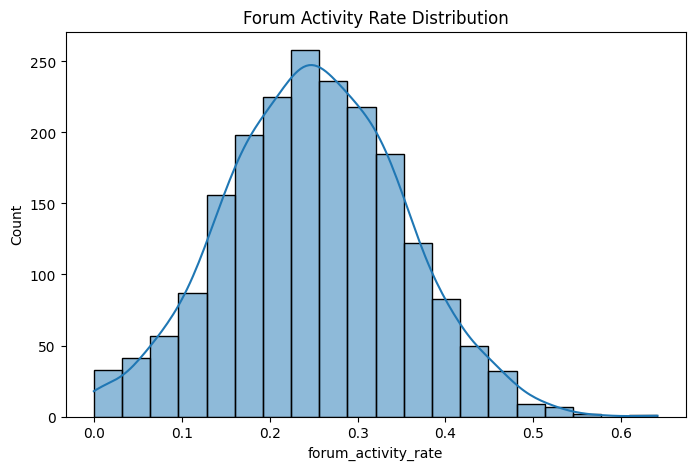

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["forum_activity_rate"], bins=20, kde=True)
plt.title("Forum Activity Rate Distribution")
plt.show()

### **EDA Summary**

The exploratory analysis highlights variations in engagement and learning outcomes across batches. Engagement indicators such as watch time, assignment submissions, and forum participation appear to influence course completion and instructor effectiveness.

## **Correlation Analysis**
Correlation analysis helps identify relationships between different variables in the dataset. Understanding these relationships allows us to determine which engagement metrics influence learning outcomes and instructor effectiveness.

In [21]:
corr = df.corr(numeric_only=True)
corr

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
completion_rate,1.000000,0.404161,0.333307,-0.953493,0.187633,0.221877,0.205793,0.315394,0.279549
avg_score_improvement,0.404161,1.000000,0.218788,-0.381354,0.128352,0.128914,0.152643,0.190054,0.198923
avg_quiz_score,0.333307,0.218788,1.000000,-0.315220,0.110648,0.115678,0.128595,0.149825,0.144783
dropout_rate,-0.953493,-0.381354,-0.315220,1.000000,-0.170536,-0.210486,-0.200598,-0.300556,-0.274475
avg_watch_time,0.187633,0.128352,0.110648,-0.170536,1.000000,0.081442,0.091414,0.117653,0.138435
assignment_submission_rate,0.221877,0.128914,0.115678,-0.210486,0.081442,1.000000,0.066776,0.070639,0.079055
forum_activity_rate,0.205793,0.152643,0.128595,-0.200598,0.091414,0.066776,1.000000,0.147115,0.126143
avg_feedback_score,0.315394,0.190054,0.149825,-0.300556,0.117653,0.070639,0.147115,1.000000,0.120092
feedback_response_rate,0.279549,0.198923,0.144783,-0.274475,0.138435,0.079055,0.126143,0.120092,1.000000


### **Correlation Heatmap Visualization**
The heatmap visually represents relationships between engagement metrics and performance indicators. Strong positive correlations suggest that as one metric increases, the other tends to increase as well, while negative correlations indicate an inverse relationship.

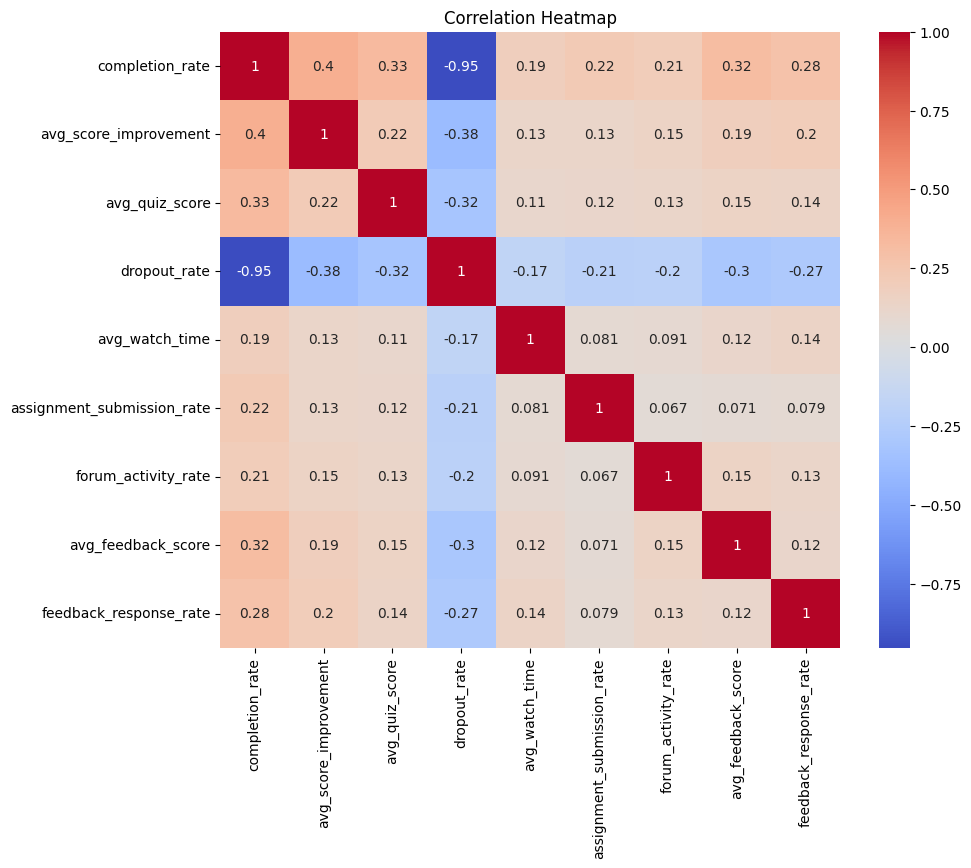

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### **Key Observations from Correlation Analysis**

• Completion rate tends to have positive relationships with engagement metrics such as watch time and assignment submission rate.  

• Dropout rate generally shows a negative relationship with course completion and engagement indicators.  

• Student feedback scores appear moderately correlated with course outcomes, indicating that instructor quality may influence learner satisfaction.

## **Feature Engineering**
Feature engineering is performed to derive meaningful metrics that represent instructor performance. A composite effectiveness score is created by combining engagement, learning outcomes, and feedback indicators.

In [23]:
df["instructor_id"].value_counts()

,count
instructor_id,
I_062,31
I_101,27
I_090,26
I_033,26
I_113,26
...,...
I_041,8
I_091,8
I_077,8


### **Creating Instructor Effectiveness Score**
A composite effectiveness score is created by combining multiple engagement and outcome indicators. Higher completion rates, assignment submissions, watch time, and feedback scores positively contribute to the effectiveness score, while higher dropout rates reduce it.

In [24]:
df["effectiveness_score"] = (
    0.30 * df["completion_rate"] +
    0.20 * df["avg_score_improvement"] +
    0.15 * df["avg_watch_time"] +
    0.15 * df["assignment_submission_rate"] +
    0.10 * df["avg_feedback_score"] -
    0.10 * df["dropout_rate"]
)

### **Effectiveness Score Distribution**
The statistical summary provides insights into the distribution of effectiveness scores across different batches.


In [25]:
df["effectiveness_score"].describe()

,effectiveness_score
count,2000.000000
mean,6.198692
std,1.186098
min,1.993724
25%,5.383909
50%,6.187582
75%,6.989237
max,9.043146


### **Categorizing Instructor Effectiveness**
The effectiveness score is divided into three tiers—Low, Medium, and High—using quantile-based binning. This categorization enables the use of classification models for predicting instructor effectiveness.

In [26]:
df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

### **Effectiveness Tier Distribution**
This step verifies the distribution of instructors across effectiveness tiers and ensures that the dataset remains balanced for machine learning modeling.


In [27]:
df["effectiveness_tier"].value_counts()

,count
effectiveness_tier,
Low,667
High,667
Medium,666


### **Instructor-Level Performance Aggregation**
Batch-level metrics are aggregated at the instructor level to evaluate overall instructor performance across multiple batches.

In [28]:
instructor_df = df.groupby("instructor_id").mean(numeric_only=True).reset_index()

### **Instructor Batch Count**
The number of batches taught by each instructor is calculated and added as a feature. This helps capture teaching experience and consistency in performance.

In [29]:
batch_counts = df.groupby("instructor_id").size().reset_index(name="batch_count")
instructor_df = instructor_df.merge(batch_counts, on="instructor_id")

### **Assigning Effectiveness Tier to Instructors**
Each instructor is assigned an effectiveness tier based on the most frequent tier observed across the batches they taught.


In [30]:
tier_df = df.groupby("instructor_id")["effectiveness_tier"].agg(lambda x: x.mode()[0]).reset_index()
instructor_df = instructor_df.merge(tier_df, on="instructor_id")

In [32]:
instructor_df.head()
instructor_df.shape

(120, 13)

The instructor-level dataset prepared above is used as input for building the machine learning model.

 ## **Machine Learning Model Development**
 To predict instructor effectiveness tiers, a machine learning model is developed using instructor-level performance metrics. The goal is to classify instructors into Low, Medium, or High effectiveness categories based on engagement and learning outcome indicators.

### **Feature Selection**
The dataset is divided into input features (X) and the target variable (y).  
The target variable represents the instructor effectiveness tier, while the remaining variables are used as predictors.

In [33]:
X = instructor_df.drop(columns=["instructor_id","effectiveness_tier"])
y = instructor_df["effectiveness_tier"]

### **Train-Test Split**
The dataset is divided into training and testing sets.  
80% of the data is used to train the model, while 20% is reserved for evaluating its performance.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Model Training**
A Random Forest classifier is trained on the training dataset.  
This model is chosen because it performs well on structured datasets and can capture complex relationships between features.

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### **Model Prediction**
The trained model is used to generate predictions for the test dataset in order to evaluate its classification performance.

In [36]:
y_pred = model.predict(X_test)

### **Model Evaluation**
Model performance is evaluated using classification metrics such as precision, recall, and accuracy. These metrics provide insights into how effectively the model predicts instructor effectiveness tiers.

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.70      0.78      0.74         9
         Low       0.86      0.86      0.86         7
      Medium       0.57      0.50      0.53         8

    accuracy                           0.71        24
   macro avg       0.71      0.71      0.71        24
weighted avg       0.70      0.71      0.70        24



## **Model Accuracy**
The model accuracy represents the proportion of correct predictions made by the machine learning model on the test dataset. A higher accuracy indicates that the model is effective in classifying instructors into the correct effectiveness tiers.


In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7083333333333334


### **Confusion Matrix**
The confusion matrix illustrates how well the model distinguishes between effectiveness tiers by comparing predicted values with actual outcomes.

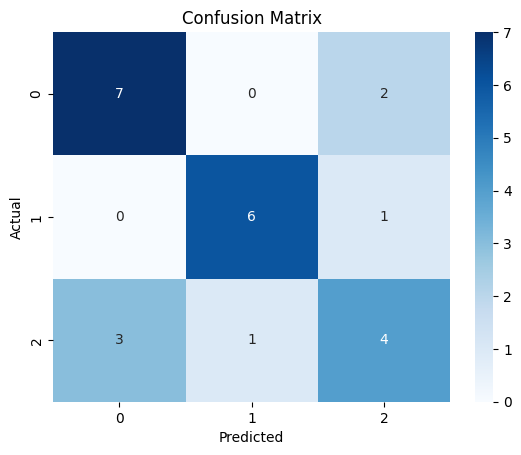

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### **Feature Importance Analysis**
Feature importance analysis identifies which variables contribute most significantly to predicting instructor effectiveness. Engagement metrics and completion rates appear to play a key role in determining instructor performance.

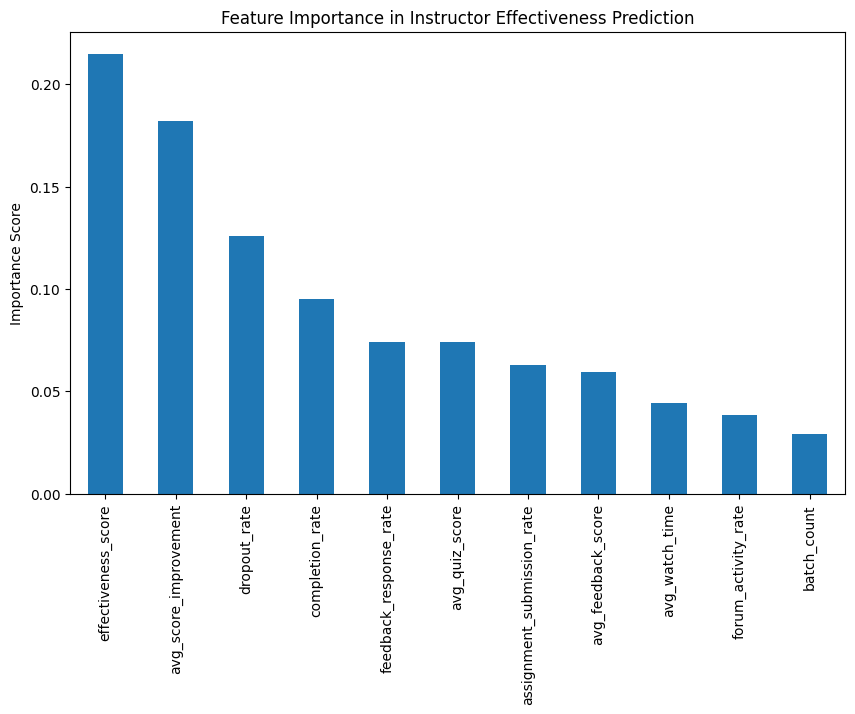

In [42]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind="bar")
plt.title("Feature Importance in Instructor Effectiveness Prediction")
plt.ylabel("Importance Score")
plt.show()

## **Top Performing Instructors**
The table above highlights the top-performing instructors based on their effectiveness scores. These instructors demonstrate strong engagement metrics, high completion rates, and positive feedback from students.

In [43]:
top_instructors = instructor_df.sort_values(
    by="effectiveness_score",
    ascending=False
).head(10)

top_instructors

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score,batch_count,effectiveness_tier
9,I_010,0.940783,34.856747,90.656473,0.068522,0.900853,0.837532,0.343266,4.552640,0.891873,7.962754,13,High
36,I_037,0.923555,34.173442,87.282865,0.086773,0.903739,0.808203,0.327316,4.532852,0.859106,7.813154,15,High
104,I_105,0.863880,33.871306,86.272878,0.141051,0.870686,0.823636,0.317997,4.507488,0.834154,7.724217,16,High
76,I_077,0.597868,34.337791,68.104292,0.406240,0.740457,0.861181,0.267647,4.056213,0.743939,7.652161,8,High
90,I_091,0.897119,33.376943,85.028412,0.116080,0.773583,0.924766,0.264921,4.490270,0.777573,7.636696,8,High
117,I_118,0.820753,32.636791,87.071798,0.202034,0.773422,0.829285,0.258419,4.641986,0.868611,7.457985,19,High
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,7.439928,19,High
17,I_018,0.867026,32.225336,89.096936,0.143953,0.882547,0.850893,0.341459,4.635637,0.781723,7.414359,14,High
55,I_056,0.702714,32.402069,84.139448,0.299814,0.781320,0.807810,0.248851,4.328810,0.796356,7.332497,14,High
14,I_015,0.780741,31.364753,79.832706,0.238809,0.867078,0.855627,0.285056,4.521249,0.777381,7.193823,17,High


In [44]:
instructor_df.to_csv("instructor_effectiveness_results.csv", index=False)

## **Distribution of Instructor Effectiveness Tiers**
This visualization illustrates the distribution of instructors across effectiveness categories. Understanding this distribution helps evaluate whether the dataset is balanced and provides insight into the overall teaching performance landscape.

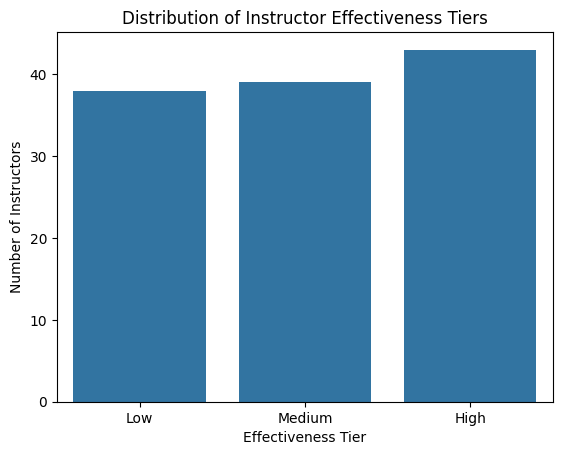

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=instructor_df, x="effectiveness_tier")
plt.title("Distribution of Instructor Effectiveness Tiers")
plt.xlabel("Effectiveness Tier")
plt.ylabel("Number of Instructors")
plt.show()

## **Engagement vs Completion Analysis**
The scatter plot illustrates the relationship between student engagement and course completion rates. Courses with higher watch time generally tend to achieve higher completion rates, suggesting that engagement plays an important role in learning outcomes.

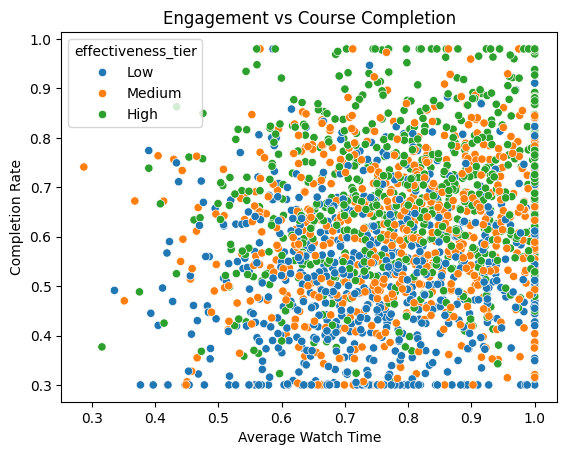

In [46]:
sns.scatterplot(
    data=df,
    x="avg_watch_time",
    y="completion_rate",
    hue="effectiveness_tier"
)

plt.title("Engagement vs Course Completion")
plt.xlabel("Average Watch Time")
plt.ylabel("Completion Rate")
plt.show()

## **Feature Importance for Instructor Effectiveness Prediction**
Feature importance analysis identifies which variables contribute the most to predicting instructor effectiveness. Metrics related to student engagement and course completion tend to have the strongest influence on instructor performance.

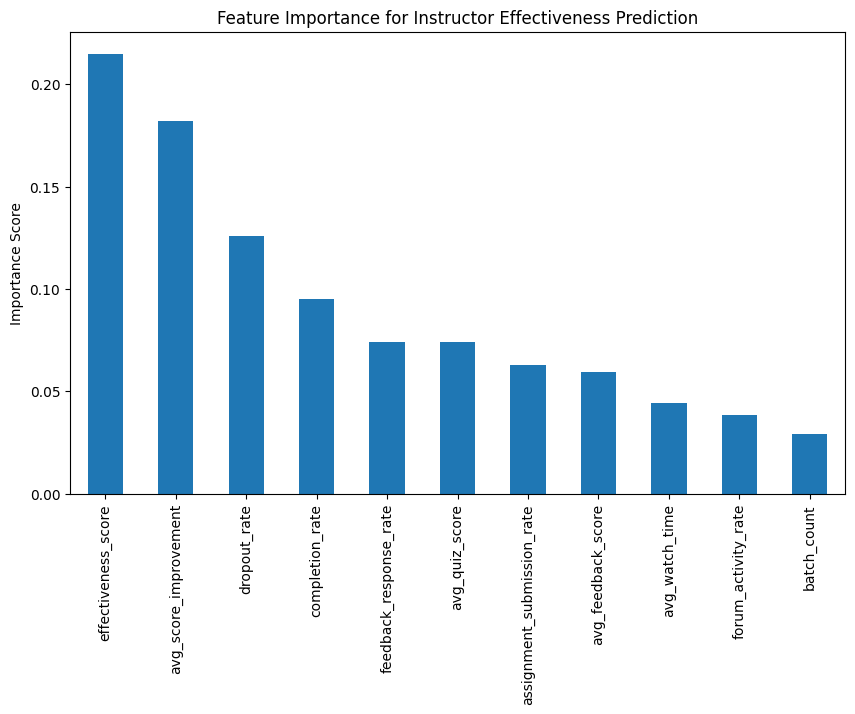

In [47]:
feature_importance.plot(kind="bar", figsize=(10,6))
plt.title("Feature Importance for Instructor Effectiveness Prediction")
plt.ylabel("Importance Score")
plt.show()

## **Key Insights**
• Instructor effectiveness is strongly influenced by course completion rates and student engagement levels.  

• Engagement indicators such as watch time and assignment submissions significantly impact learning outcomes.  

• Higher dropout rates are associated with lower instructor effectiveness.  

• Student feedback scores provide valuable insights into teaching quality and course satisfaction.  

• Machine learning models can successfully identify patterns in engagement data to predict instructor performance.

## **Business Impact and Practical Applications**
The findings from this analysis highlight how learning analytics can support data-driven decision making in online education platforms.

By identifying key drivers of instructor effectiveness such as student engagement, completion rates, and feedback scores, educational organizations can:

• Identify high-performing instructors and replicate their teaching strategies across courses.  

• Detect underperforming courses early and provide targeted improvements.  

• Enhance student engagement through data-informed instructional practices.  

• Improve overall course completion rates and learning outcomes.  

• Develop scalable instructor evaluation frameworks based on objective performance metrics.

Incorporating predictive models into learning platforms can further enable proactive monitoring of instructor performance, allowing organizations to continuously improve educational quality and student success.

## **Conclusion**
This project demonstrates how data analytics and machine learning can be used to evaluate instructor effectiveness in online learning environments. By analyzing engagement metrics, course completion rates, and feedback indicators, meaningful insights into teaching performance can be derived.

The machine learning model developed in this study successfully classifies instructors into effectiveness tiers, highlighting the importance of engagement-driven learning strategies. These findings suggest that educational platforms can leverage learning analytics to identify high-performing instructors, enhance teaching practices, and improve overall student learning outcomes.

In the future, incorporating additional variables such as course difficulty, learner demographics, and behavioral analytics could further improve predictive performance and enable more comprehensive evaluation of instructional quality.
